# 02 Your First Data Cube: Real MODIS NDVI over Pine Ridge

**Tutorial:** Building Geospatial Data Cubes for Earth Data Science  
**Focus:** Pine Ridge (Oglala Lakota Nation), South Dakota  
**Prerequisites:** Notebooks 00 and 01  

## What This Notebook Does
In notebooks 00 and 01 we built data cubes from synthetic numbers.
In this notebook we build one from **real satellite data**.

We will:
1. Download real MODIS NDVI observations for Pine Ridge (2000–2023)
2. Build a labeled xarray DataArray (a 1D time series cube)
3. Add the Pine Ridge boundary as spatial context
4. Explore the data for seasonal patterns, long-term trends, low years
5. Save the cube with provenance metadata

## What Is NDVI?
Normalized Difference Vegetation Index (NDVI) measures how green and
dense the vegetation is at a given location. It is derived from satellite
imagery by comparing how much near-infrared and red light the land reflects.
Healthy grass and plants absorb red light and reflect near-infrared;
bare soil and drought-stressed vegetation do the opposite.

| NDVI range | Condition |
|---|---|
| 0.0 – 0.2 | Bare soil, rock, or snow |
| 0.2 – 0.35 | Sparse or stressed vegetation |
| 0.35 – 0.5 | Moderate vegetation (typical Pine Ridge growing season) |
| 0.5 – 0.8 | Dense, healthy vegetation |

## Data Source
We use MODIS MOD13Q1, NASA's 16-day composite NDVI product at 250m
resolution. Data is retrieved via the ORNL DAAC MODIS Web Service API
(no account required for point queries).

First run: downloads ~300 API calls for 24 years × 8 Tribes and could take
5–10 minutes. All results cache to `data/cache/` so subsequent runs
are instant.

In [1]:
# Imports
import sys
from pathlib import Path

# Add the src/directory to the Python path
REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import warnings
from scipy import stats

from src.cube_utils import (
    load_pine_ridge_boundary,
    load_sd_tribal_boundaries,
    fetch_ndvi_timeseries,
    timeseries_to_dataarray,
    compute_growing_season_mean,
    compute_anomaly,
    CACHE_DIR,
)

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

print(f"Repository root : {REPO_ROOT}")
print(f"Cache directory : {CACHE_DIR}")

Repository root : /workspaces/Education-data_cube_tutorial
Cache directory : /workspaces/Education-data_cube_tutorial/data/cache


In [2]:
# Analysis parameters

# Pine Ridge centroid (used for point NDVI query)
PINE_RIDGE_LAT =  43.35
PINE_RIDGE_LON = -102.09

# Analysis period (MODIS available from 2000)
START_YEAR = 2000
END_YEAR   = 2023

# May-September growing season for Great Plains mixed-grass prairie
GROWING_MONTHS = [5, 6, 7, 8, 9]   

print("ANALYSIS PARAMETERS")
print(f"  Location : Pine Ridge (Oglala Lakota Nation)")
print(f"  Centroid : {PINE_RIDGE_LAT}°N, {PINE_RIDGE_LON}°W")
print(f"  Period   : {START_YEAR}–{END_YEAR}")
print(f"  Dataset  : MODIS MOD13Q1 (16-day, 250m NDVI)")

ANALYSIS PARAMETERS
  Location : Pine Ridge (Oglala Lakota Nation)
  Centroid : 43.35°N, -102.09°W
  Period   : 2000–2023
  Dataset  : MODIS MOD13Q1 (16-day, 250m NDVI)


## Load the Boundary

In [4]:
# Load Pine Ridge boundary from Census TIGER
# (Downloads and caches on first run)

pine_ridge = load_pine_ridge_boundary()

print(f"Pine Ridge boundary loaded: {len(pine_ridge)} feature(s)")
print(f"CRS: {pine_ridge.crs}")

# Compute area in square miles for context
area_sq_mi = pine_ridge.to_crs("EPSG:5070").geometry.area.sum() / 2.59e6
print(f"Area: {area_sq_mi:,.0f} square miles")
print("(For reference: Connecticut is ~5,543 sq mi)")

Pine Ridge boundary loaded: 1 feature(s)
CRS: EPSG:4326
Area: 4,353 square miles
(For reference: Connecticut is ~5,543 sq mi)


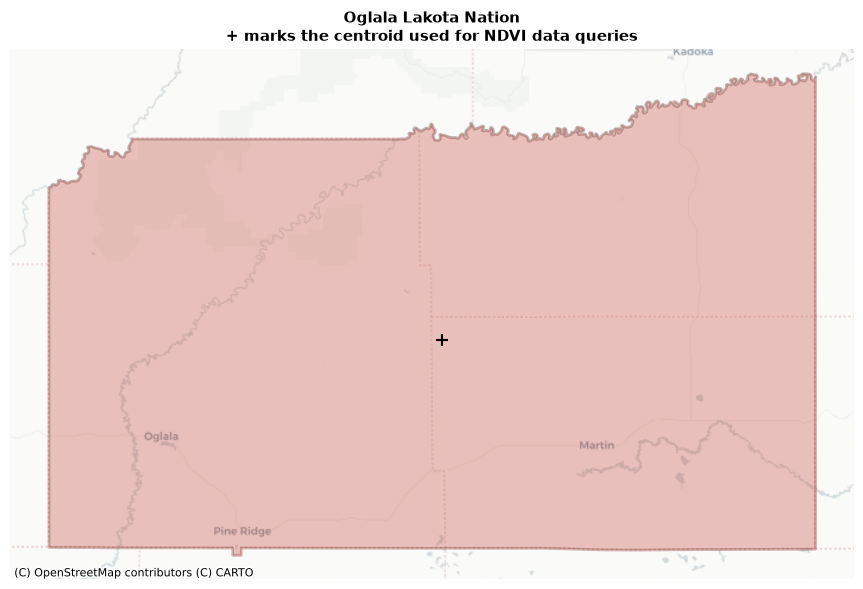

In [5]:
# Quick map to orient ourselves
fig, ax = plt.subplots(figsize=(10, 6))
pine_ridge.to_crs(3857).plot(
    ax=ax, facecolor="#C0392B", alpha=0.3,
    edgecolor="#7B241C", linewidth=2,
)
# Mark the centroid used for NDVI queries
import shapely.geometry as sg
centroid_gdf = gpd.GeoDataFrame(
    geometry=[sg.Point(PINE_RIDGE_LON, PINE_RIDGE_LAT)],
    crs="EPSG:4326",
).to_crs(3857)
centroid_gdf.plot(ax=ax, color="black", markersize=80, marker="+", zorder=5)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
except Exception:
    pass

ax.set_axis_off()
ax.set_title(
    "Oglala Lakota Nation\n"
    "+ marks the centroid used for NDVI data queries",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

## Fetch NDVI Data

In [6]:
# Fetch MODIS NDVI for Pine Ridge centroid
# First run: several minutes (25 years × API calls)
# Subsequent runs: instant from cache

ndvi_df = fetch_ndvi_timeseries(
    lat        = PINE_RIDGE_LAT,
    lon        = PINE_RIDGE_LON,
    start_year = START_YEAR,
    end_year   = END_YEAR,
    site_name  = "pine_ridge",
)

print(f"\nNDVI data loaded: {len(ndvi_df):,} observations")
print(f"Date range: {ndvi_df['date'].min().date()} to {ndvi_df['date'].max().date()}")
print(f"\nFirst few rows:")
print(ndvi_df.head(6).to_string(index=False))


NDVI data loaded: 549 observations
Date range: 2000-02-18 to 2023-12-19

First few rows:
      date   ndvi  pixel_count
2000-02-18 0.2409          289
2000-03-05 0.2387          289
2000-03-21 0.2423          289
2000-04-06 0.2555          289
2000-04-22 0.3028          289
2000-05-08 0.4256          289


## Build the Data Cube

In [7]:
# Convert the DataFrame to a labeled xarray DataArray
# This is the step that turns tabular data into a data cube

ndvi_da = timeseries_to_dataarray(
    df        = ndvi_df,
    date_col  = "date",
    value_col = "ndvi",
    name      = "ndvi",
    attrs     = {
        "long_name":     "Normalized Difference Vegetation Index",
        "units":         "dimensionless (0–1)",
        "valid_range":   [0, 1],
        "source":        "MODIS MOD13Q1 V061 via ORNL DAAC",
        "spatial_res":   "250m point centroid average (±2km)",
        "temporal_res":  "16-day composite",
        "location":      "Pine Ridge, Oglala Lakota Nation",
        "centroid_lat":  PINE_RIDGE_LAT,
        "centroid_lon":  PINE_RIDGE_LON,
        # Data governance
        "tk_community":  "Oglala Lakota Nation",
        "tk_usage":      "Environmental research: this data describes Tribal lands",
        "care_note":     "Analysis results should benefit the Oglala Lakota community",
        "ieee_2890":     "https://standards.ieee.org/ieee/2890/10318/",
    }
)

print("DataArray built:")
print(ndvi_da)
print(f"\nDimensions : {ndvi_da.dims}")
print(f"Shape      : {ndvi_da.shape}")
print(f"Time range : {str(ndvi_da.time.values[0])[:10]} to {str(ndvi_da.time.values[-1])[:10]}")

DataArray built:
<xarray.DataArray 'ndvi' (time: 549)> Size: 4kB
array([ 2.409e-01,  2.387e-01,  2.423e-01,  2.555e-01,  3.028e-01,
        4.256e-01,  5.353e-01,  5.911e-01,  5.911e-01,  6.096e-01,
        5.427e-01,  4.439e-01,  4.288e-01,  3.938e-01,  3.365e-01,
        3.026e-01,  2.764e-01,  1.600e-02,  3.820e-02,  4.940e-02,
        1.633e-01,  6.080e-02,  1.150e-02,  1.280e-02,  6.020e-02,
        2.269e-01,  2.587e-01,  3.777e-01,  3.875e-01,  5.448e-01,
        5.812e-01,  6.212e-01,  6.515e-01,  6.064e-01,  5.448e-01,
        4.766e-01,  4.113e-01,  3.635e-01,  3.323e-01,  3.022e-01,
        1.768e-01,  1.314e-01,  2.042e-01,  2.469e-01,  2.362e-01,
        2.361e-01,  2.109e-01,  2.410e-02,  2.120e-01,  2.544e-01,
        2.933e-01,  3.495e-01,  4.473e-01,  4.676e-01,  4.100e-01,
        3.550e-01,  3.483e-01,  3.495e-01,  3.789e-01,  4.101e-01,
        3.946e-01,  3.575e-01,  3.185e-01,  3.058e-01,  2.849e-01,
        2.821e-01,  2.819e-01,  1.496e-01,  3.700e-02,  2.391e-0

## Explore the Data

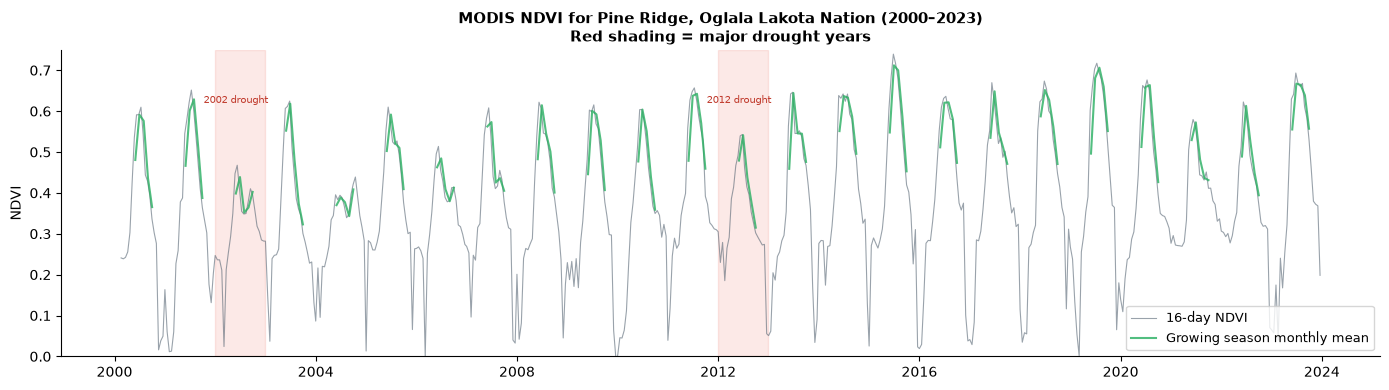

In [8]:
# Full time series
fig, ax = plt.subplots(figsize=(14, 4))

ndvi_da.plot(ax=ax, color="#566573", linewidth=0.8, alpha=0.6, label="16-day NDVI")

# Growing season monthly means
gs_monthly = ndvi_da.sel(
    time=ndvi_da["time"].dt.month.isin(GROWING_MONTHS)
).resample(time="ME").mean()
gs_monthly.plot(ax=ax, color="#27AE60", linewidth=1.5, alpha=0.8,
                label="Growing season monthly mean")

# Mark known major drought years
for yr, label in [(2002, "2002 drought"), (2012, "2012 drought")]:
    ax.axvspan(
        pd.Timestamp(f"{yr}-01-01"),
        pd.Timestamp(f"{yr}-12-31"),
        color="#E74C3C", alpha=0.12,
    )
    ax.text(
        pd.Timestamp(f"{yr}-06-01"), 0.62, label,
        fontsize=7, color="#C0392B", ha="center",
    )

ax.set_ylim(0, 0.75)
ax.set_xlabel("")
ax.set_ylabel("NDVI")
ax.set_title(
    "MODIS NDVI for Pine Ridge, Oglala Lakota Nation (2000–2023)\n"
    "Red shading = major drought years",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
import seaborn as sns
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

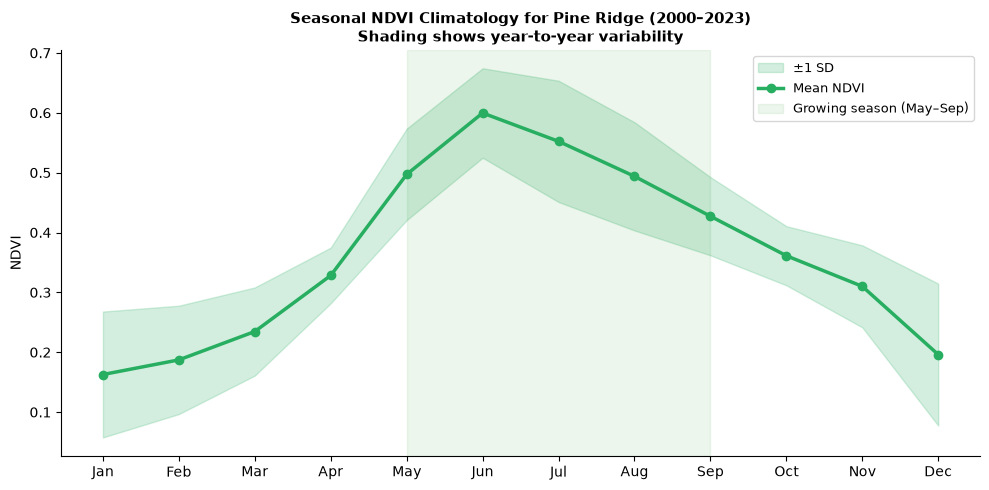

In [9]:
# Seasonal climatology: what does a typical year look like?
month_mean = ndvi_da.groupby("time.month").mean()
month_std  = ndvi_da.groupby("time.month").std()

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(
    range(1, 13),
    (month_mean - month_std).values,
    (month_mean + month_std).values,
    color="#27AE60", alpha=0.2, label="±1 SD",
)
ax.plot(range(1, 13), month_mean.values,
        color="#27AE60", linewidth=2.5, marker="o",
        markersize=6, label="Mean NDVI")

# Shade growing season
ax.axvspan(5, 9, alpha=0.07, color="green", label="Growing season (May–Sep)")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel("NDVI")
ax.set_title(
    "Seasonal NDVI Climatology for Pine Ridge (2000–2023)\n"
    "Shading shows year-to-year variability",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [10]:
# Annual growing season means: which years were best and worst?
ndvi_annual = compute_growing_season_mean(ndvi_da, months=GROWING_MONTHS)

print("Annual growing season mean NDVI for Pine Ridge:")

# Sort to show best and worst years
annual_df = ndvi_annual.to_dataframe(name="ndvi").reset_index()
print("\nTop 5 years (greenest):")
print(annual_df.nlargest(5, "ndvi")[["year", "ndvi"]].round(4).to_string(index=False))
print("\nBottom 5 years (least green/drought years):")
print(annual_df.nsmallest(5, "ndvi")[["year", "ndvi"]].round(4).to_string(index=False))

Annual growing season mean NDVI for Pine Ridge:

Top 5 years (greenest):
 year   ndvi
 2019 0.6188
 2023 0.6164
 2015 0.5996
 2014 0.5806
 2018 0.5796

Bottom 5 years (least green/drought years):
 year   ndvi
 2004 0.3775
 2002 0.3911
 2012 0.4294
 2006 0.4296
 2003 0.4695


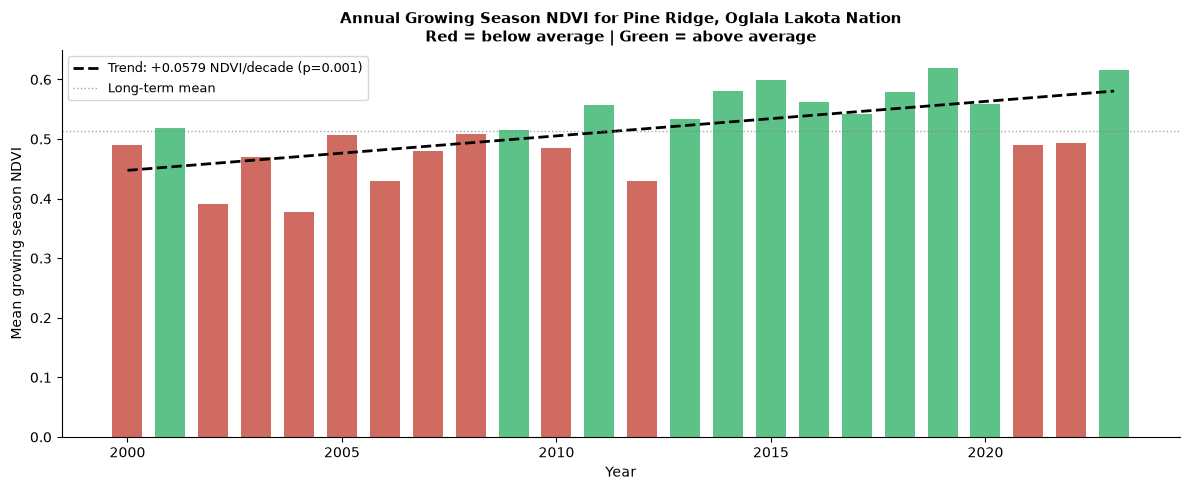


Trend: increasing at +0.0579 NDVI units per decade (statistically significant, p=0.001)


In [11]:
# Long-term trends: is Pine Ridge getting greener or less green?

years  = annual_df["year"].values.astype(float)
values = annual_df["ndvi"].values

slope, intercept, r, p, se = stats.linregress(years, values)
trend_line = slope * years + intercept

fig, ax = plt.subplots(figsize=(12, 5))

colors = [
    "#C0392B" if v < annual_df["ndvi"].mean() else "#27AE60"
    for v in values
]
ax.bar(years, values, color=colors, alpha=0.75, width=0.7)
ax.plot(years, trend_line, color="black", linewidth=2,
        linestyle="--", label=f"Trend: {slope*10:+.4f} NDVI/decade (p={p:.3f})")
ax.axhline(annual_df["ndvi"].mean(), color="gray",
           linewidth=1, linestyle=":", alpha=0.7, label="Long-term mean")

ax.set_xlabel("Year")
ax.set_ylabel("Mean growing season NDVI")
ax.set_title(
    "Annual Growing Season NDVI for Pine Ridge, Oglala Lakota Nation\n"
    "Red = below average | Green = above average",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

direction = "increasing" if slope > 0 else "decreasing"
sig = "statistically significant" if p < 0.05 else "not statistically significant"
print(f"\nTrend: {direction} at {slope*10:+.4f} NDVI units per decade ({sig}, p={p:.3f})")

## Save the Cube with Provenance Metadata

In [12]:
# Wrap the DataArray in a Dataset with provenance metadata
# This is good practice so that the cube travels with its documentation
# and Tribal data sovereignty is preserved.
import datetime

cube = xr.Dataset(
    data_vars = {"ndvi": ndvi_da},
    attrs = {
        # What this is
        "title":         "MODIS NDVI Time Series for Pine Ridge, Oglala Lakota Nation",
        "summary":       "16-day MODIS MOD13Q1 NDVI point time series for Pine Ridge centroid",
        # Where it comes from
        "source":        "MODIS MOD13Q1 V061, NASA ORNL DAAC MODIS Web Service",
        "source_url":    "https://modis.ornl.gov/rst/api/v1/",
        # When it was created
        "created":       datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "created_by":    "tribal_datacube_tutorial notebook 02",
        # Spatial context
        "location":      "Pine Ridge Reservation, Oglala Lakota Nation",
        "centroid_lat":  PINE_RIDGE_LAT,
        "centroid_lon":  PINE_RIDGE_LON,
        # Data governance — IEEE 2890-2025 aligned
        "tk_community":  "Oglala Lakota Nation",
        "tk_usage":      "Non-commercial environmental research",
        "care_c":        "Analysis results should benefit the Oglala Lakota community",
        "care_a":        "Oglala Lakota Nation has authority over use of results",
        "ieee_2890":     "https://standards.ieee.org/ieee/2890/10318/",
        # Technical
        "conventions":   "CF-1.8",
        "crs":           "EPSG:4326 (WGS84)",
    }
)

# Save as NetCDF
output_path = CACHE_DIR/"pine_ridge_ndvi_cube.nc"
cube.to_netcdf(output_path)
print(f"Cube saved: {output_path}")
print(f"File size : {output_path.stat().st_size / 1024:.1f} KB")
print()
print(cube)

Cube saved: /workspaces/Education-data_cube_tutorial/data/cache/pine_ridge_ndvi_cube.nc
File size : 21.4 KB

<xarray.Dataset> Size: 9kB
Dimensions:  (time: 549)
Coordinates:
  * time     (time) datetime64[us] 4kB 2000-02-18 2000-03-05 ... 2023-12-19
Data variables:
    ndvi     (time) float64 4kB 0.2409 0.2387 0.2423 ... 0.3722 0.3683 0.1983
Attributes: (12/16)
    title:         MODIS NDVI Time Series for Pine Ridge, Oglala Lakota Nation
    summary:       16-day MODIS MOD13Q1 NDVI point time series for Pine Ridge...
    source:        MODIS MOD13Q1 V061, NASA ORNL DAAC MODIS Web Service
    source_url:    https://modis.ornl.gov/rst/api/v1/
    created:       2026-07-10T19:22:36.023046+00:00
    created_by:    tribal_datacube_tutorial notebook 02
    ...            ...
    tk_usage:      Non-commercial environmental research
    care_c:        Analysis results should benefit the Oglala Lakota community
    care_a:        Oglala Lakota Nation has authority over use of results
    ieee_

## Extending to Other Oceti Sakowin Nations

The same pattern works for all Oceti Sakowin Tribal Nations in South Dakota.
The cell below fetches NDVI for all Tribes and compares them.

In [13]:
# Load Tribal boundaries and compute centroids
sd_tribes = load_sd_tribal_boundaries()

centroids = sd_tribes.to_crs("EPSG:5070").geometry.centroid.to_crs("EPSG:4326")
sd_tribes["centroid_lat"] = centroids.y
sd_tribes["centroid_lon"] = centroids.x

print(f"SD Tribal Nations: {len(sd_tribes)}")
print(sd_tribes[["common_name", "centroid_lat", "centroid_lon"]].to_string(index=False))

SD Tribal Nations: 8
            common_name  centroid_lat  centroid_lon
   Cheyenne River Sioux     45.076296   -101.225719
       Crow Creek Sioux     44.128748    -99.474031
 Flandreau Santee Sioux     44.074150    -96.573921
Sisseton Wahpeton Oyate     45.644528    -97.098750
      Lower Brule Sioux     44.089706    -99.771141
          Oglala Lakota     43.353167   -102.089183
          Rosebud Sioux     43.307932   -100.641682
    Standing Rock Sioux     45.833097   -101.148983


In [14]:
# Fetch NDVI for all Tribal Nations in SD
# First run: several minutes. Subsequent runs: instant from cache.

all_annual = {}

for _, tribe in sd_tribes.iterrows():
    name = tribe["common_name"]
    try:
        df = fetch_ndvi_timeseries(
            lat=tribe["centroid_lat"],
            lon=tribe["centroid_lon"],
            start_year=START_YEAR,
            end_year=END_YEAR,
            site_name=name,
        )
        da      = timeseries_to_dataarray(df, name=name)
        annual  = compute_growing_season_mean(da, months=GROWING_MONTHS)
        all_annual[name] = annual
    except Exception as e:
        print(f"  {name}: failed {e}")

print(f"\nNDVI annual means loaded for {len(all_annual)} Tribal Nations")


NDVI annual means loaded for 8 Tribal Nations


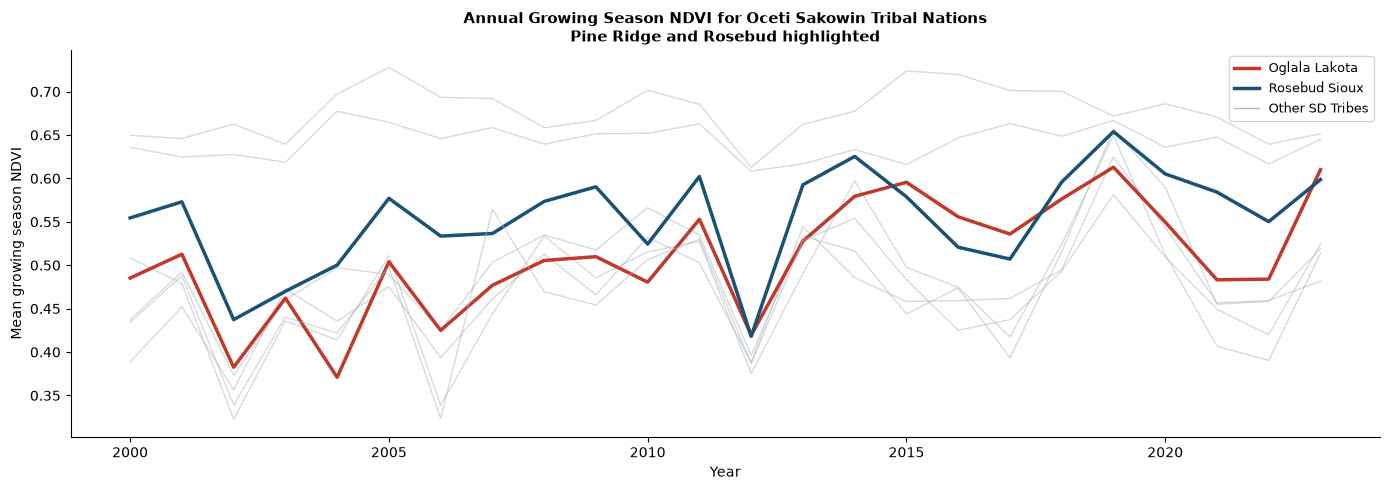

In [15]:
# Compare growing season NDVI across Tribal Nations
if all_annual:
    fig, ax = plt.subplots(figsize=(14, 5))

    for name, annual in all_annual.items():
        color = "#C0392B" if name == "Oglala Lakota" else \
                "#1A5276" if name == "Rosebud Sioux" else "#AEB6BF"
        lw    = 2.5 if name in ("Oglala Lakota", "Rosebud Sioux") else 1.0
        alpha = 1.0 if name in ("Oglala Lakota", "Rosebud Sioux") else 0.5
        ax.plot(
            annual.year.values, annual.values,
            color=color, linewidth=lw, alpha=alpha,
            label=name if name in ("Oglala Lakota", "Rosebud Sioux") else "_nolegend_",
        )

    ax.set_xlabel("Year")
    ax.set_ylabel("Mean growing season NDVI")
    ax.set_title(
        "Annual Growing Season NDVI for Oceti Sakowin Tribal Nations\n"
        "Pine Ridge and Rosebud highlighted",
        fontsize=11, fontweight="bold",
    )
    # Add gray line label
    ax.plot([], [], color="#AEB6BF", linewidth=1, label="Other SD Tribes")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

## Summary

You just built your first real data cube:
- **Real satellite data** from MODIS MOD13Q1
- **Labeled time dimension** so you can select by date
- **Provenance metadata** documenting source, location, and governance
- **Saved as NetCDF** so the cube and its documentation travel together

## Discussion Questions
1. Look at the annual NDVI chart. Can you identify any years that look
   unusually low? Do those correspond to drought years you know about?

2. The NDVI data comes from a satellite that measures reflected light.
   What conditions on the ground might cause low NDVI that are NOT drought?
   (Think about what else could reduce vegetation greenness.)

3. The provenance metadata includes a `care_a` field saying the Oglala
   Lakota Nation has authority over use of results. What does that mean
   in practice if you wanted to publish an analysis using this data?

## Next Notebook

**03 Time Slicing:** We'll learn to query the data cube across time by
selecting drought years, computing anomalies, and comparing specific
seasons across decades.